In [8]:
#Data Simulation

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt

np.random.seed(42)
n_samples = 500
runtime_hours = np.linspace(0, 1000, n_samples)
temperature = 40 + 0.03 * runtime_hours + np.random.normal(0, 2, n_samples)
vibration = 1 + 0.002 * runtime_hours + np.random.normal(0, 0.3, n_samples)

df = pd.DataFrame({
    "runtime_hours": runtime_hours,
    "temperature": temperature,
    "vibration": vibration
})


In [9]:
#Failure Labelling

runtime_threshold = df["runtime_hours"].quantile(0.85)
temp_threshold = df["temperature"].quantile(0.85)
vib_threshold = df["vibration"].quantile(0.85)

df["failure"] = (
    (df["runtime_hours"] > runtime_threshold) &
    (df["temperature"] > temp_threshold) &
    (df["vibration"] > vib_threshold)
).astype(int)

print(df["failure"].value_counts())

failure
0    464
1     36
Name: count, dtype: int64


In [3]:
# Feature Engineering — rolling averages and rate of change

df["temp_rolling_avg"] = df["temperature"].rolling(window=10).mean()
df["vib_rolling_avg"]  = df["vibration"].rolling(window=10).mean()

df["temp_rate_of_change"] = df["temperature"].diff()
df["vib_rate_of_change"]  = df["vibration"].diff()

df = df.dropna()  # rolling creates NaN in first 9 rows
df.head()

,runtime_hours,temperature,vibration,failure,temp_rolling_avg,vib_rolling_avg,temp_rate_of_change,vib_rate_of_change
9,18.036072,41.626202,0.786787,0,41.166663,0.976739,2.084189,-0.259834
10,20.040080,39.674367,1.121217,0,41.034757,0.961075,-1.951835,0.334430
11,22.044088,39.729863,1.029017,0,41.029384,0.906293,0.055496,-0.092200
12,24.048096,41.205367,0.976412,0,41.008359,0.945090,1.475504,-0.052605
13,26.052104,36.955003,0.779835,0,40.381218,0.904982,-4.250365,-0.196577


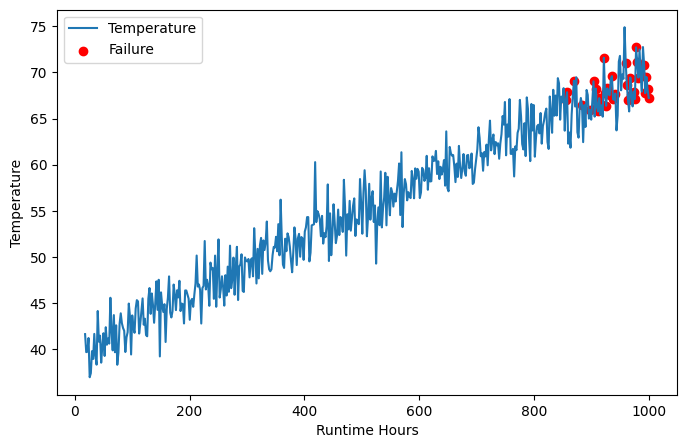

Healthy mean temperature: 54.23893391306078
Failed mean temperature: 68.28007314838538
Healthy mean vibration: 1.9477642383636355
Failed mean vibration: 3.043349752116333


In [4]:
#EDA plots

plt.figure(figsize=(8, 5))
plt.plot(df["runtime_hours"], df["temperature"], label="Temperature")
plt.scatter(
    df[df["failure"]==1]["runtime_hours"],
    df[df["failure"]==1]["temperature"],
    color="red", label="Failure"
)
plt.xlabel("Runtime Hours")
plt.ylabel("Temperature")
plt.legend()
plt.show()

healthy = df[df["failure"] == 0]
failed  = df[df["failure"] == 1]
print("Healthy mean temperature:", healthy["temperature"].mean())
print("Failed mean temperature:",  failed["temperature"].mean())
print("Healthy mean vibration:",   healthy["vibration"].mean())
print("Failed mean vibration:",    failed["vibration"].mean())

In [5]:
#Rule Based Checks

def rule_based_risk(temp, vib):
    if temp < temp_threshold and vib < vib_threshold:
        return "Low"
    elif temp < temp_threshold or vib < vib_threshold:
        return "Medium"
    else:
        return "High"

df["risk_level"] = df.apply(
    lambda row: rule_based_risk(row["temperature"], row["vibration"]), axis=1
)
print(df["risk_level"].value_counts())

risk_level
Low       384
Medium     64
High       43
Name: count, dtype: int64


In [6]:
#ML Models

X = df[["temperature", "vibration", 
        "temp_rolling_avg", "vib_rolling_avg",
        "temp_rate_of_change", "vib_rate_of_change"]]
y = df["failure"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

print("Training distribution:")
print(y_train.value_counts())

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

Training distribution:
failure
0    341
1     27
Name: count, dtype: int64
              precision    recall  f1-score   support

           0       0.97      0.98      0.98       114
           1       0.75      0.67      0.71         9

    accuracy                           0.96       123
   macro avg       0.86      0.82      0.84       123
weighted avg       0.96      0.96      0.96       123

[[112   2]
 [  3   6]]


In [7]:
#Predict on New Sensor Data

new_data = pd.DataFrame({
    "temperature":          [65,    75,    90  ],
    "vibration":            [1.8,   2.5,   3.5 ],
    "temp_rolling_avg":     [64.0,  74.0,  88.0],
    "vib_rolling_avg":      [1.75,  2.45,  3.40],
    "temp_rate_of_change":  [0.1,   0.3,   0.8 ],
    "vib_rate_of_change":   [0.02,  0.05,  0.15]
})

probabilities = model.predict_proba(new_data)
results = new_data.copy()
results["Failure Probability"] = probabilities[:, 1]

def probability_to_risk(p):
    if p < 0.3:   return "Low Risk"
    elif p < 0.7: return "Medium Risk"
    else:         return "High Risk"

results["Risk Category"] = results["Failure Probability"].apply(probability_to_risk)
print(results)

   temperature  vibration  temp_rolling_avg  vib_rolling_avg  \
0           65        1.8              64.0             1.75   
1           75        2.5              74.0             2.45   
2           90        3.5              88.0             3.40   

   temp_rate_of_change  vib_rate_of_change  Failure Probability Risk Category  
0                  0.1                0.02             0.003791      Low Risk  
1                  0.3                0.05             0.994173     High Risk  
2                  0.8                0.15             1.000000     High Risk  
